In [1]:
# ── CELL 1: Session Setup (Full 250k Dataset) ────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
import torch

# Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Recreate symlink (lost every session)
v4_dir = '/content/deepmimo_scenarios'
os.makedirs(v4_dir, exist_ok=True)
symlink_path = os.path.join(v4_dir, 'o1_28')
if not os.path.exists(symlink_path):
    os.symlink('/content/drive/MyDrive/GNN_Wireless_Research/O1_28', symlink_path)
    print("Symlink recreated")
else:
    print("Symlink ready")

# Load both chunks and stitch them together
print("\nLoading datasets from Drive...")
SAVE_PATH = '/content/drive/MyDrive/GNN_Wireless_Research/'

H_50k  = torch.load(os.path.join(SAVE_PATH, 'H_50k_normalized.pt'), map_location=device)
H_200k = torch.load(os.path.join(SAVE_PATH, 'H_200k_users_batch_2.pt'), map_location=device)

H = torch.cat([H_50k, H_200k], dim=0)

# Clear the intermediate chunks from memory
del H_50k, H_200k

print(f"🚀 Master Dataset Loaded!")
print(f"Shape: {H.shape} | Dtype: {H.dtype} | Device: {H.device}")
print(f"VRAM used by H: ~{H.nbytes/1e6:.1f} MB")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Symlink recreated

Loading datasets from Drive...
🚀 Master Dataset Loaded!
Shape: torch.Size([250000, 64]) | Dtype: torch.complex64 | Device: cuda:0
VRAM used by H: ~128.0 MB


In [2]:
# ── CELL 3: Complex Architecture Foundation (Linear + GAT) ─────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. The Pure Complex Linear Transformation
class ComplexLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(ComplexLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Explicit weights, NO messy biases
        self.real_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.imag_weight = nn.Parameter(torch.Tensor(out_features, in_features))

        nn.init.xavier_uniform_(self.real_weight)
        nn.init.xavier_uniform_(self.imag_weight)

    def forward(self, x):
        # Math: (A + iB)(C + iD) = (AC - BD) + i(BC + AD)
        real_out = torch.matmul(x.real, self.real_weight.t()) - torch.matmul(x.imag, self.imag_weight.t())
        imag_out = torch.matmul(x.imag, self.real_weight.t()) + torch.matmul(x.real, self.imag_weight.t())
        return torch.complex(real_out, imag_out)


# 2. The Complex Graph Attention Layer (Eq 8-11)
class ComplexGATLayer(nn.Module):
    def __init__(self, in_features, out_features, dropout=0.2, alpha=0.2):
        super(ComplexGATLayer, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.dropout = dropout
        self.alpha = alpha

        # Eq 9/10: The complex weight matrix W
        self.complex_linear = ComplexLinear(in_features, out_features)

        # Eq 9: The attention vector 'a'
        self.a_real = nn.Parameter(torch.Tensor(2 * out_features, 1))
        self.a_imag = nn.Parameter(torch.Tensor(2 * out_features, 1))

        nn.init.xavier_uniform_(self.a_real)
        nn.init.xavier_uniform_(self.a_imag)
        self.leakyrelu = nn.LeakyReLU(self.alpha)

    def forward(self, x, adj):
        # x shape: [N, in_features] (complex64)
        # adj shape: [N, N] (float32)
        N = x.size(0)

        # 1. Feature Transformation: h = W * x
        h = self.complex_linear(x) # shape: [N, out_features]

        # 2. Prepare for attention: Concatenate every node pair [h_i || h_j]
        h_i = h.unsqueeze(1).repeat(1, N, 1)
        h_j = h.unsqueeze(0).repeat(N, 1, 1)
        h_concat = torch.cat([h_i, h_j], dim=-1) # shape: [N, N, 2 * out_features]

        # 3. Complex Attention Scoring: a^T [W h_i || W h_j]
        e_real = torch.matmul(h_concat.real, self.a_real) - torch.matmul(h_concat.imag, self.a_imag)
        e_imag = torch.matmul(h_concat.imag, self.a_real) + torch.matmul(h_concat.real, self.a_imag)
        e_complex = torch.complex(e_real, e_imag).squeeze(-1) # shape: [N, N]

        # Eq 9 (Modified): Take magnitude of the complex score for real probability
        e_magnitude = e_complex.abs()
        e = self.leakyrelu(e_magnitude) # shape: [N, N] (real)

        # Eq 8: Mask with adjacency matrix and apply Softmax
        zero_vec = -9e15 * torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)
        attention = F.softmax(attention, dim=1) # shape: [N, N] (real)
        attention = F.dropout(attention, self.dropout, training=self.training)

        # Eq 10/11: Aggregation (Real attention * Complex features)
        h_out = torch.matmul(attention.to(h.dtype), h) # shape: [N, out_features] (complex)

        return h_out

# --- Quick Sanity Check ---
if __name__ == "__main__":
    print("\n--- Complex Architecture Verification ---")

    num_nodes = 8
    gat_layer = ComplexGATLayer(in_features=64, out_features=32).to(device)

    test_x = H[:num_nodes].to(device)
    test_adj = (torch.ones(num_nodes, num_nodes) - torch.eye(num_nodes)).to(device)

    test_out = gat_layer(test_x, test_adj)

    print(f"Input shape:  {test_x.shape} | dtype: {test_x.dtype}")
    print(f"Output shape: {test_out.shape} | dtype: {test_out.dtype}")
    print("✅ Forward pass successful. Phase data preserved.")


--- Complex Architecture Verification ---
Input shape:  torch.Size([8, 64]) | dtype: torch.complex64
Output shape: torch.Size([8, 32]) | dtype: torch.complex64
✅ Forward pass successful. Phase data preserved.


In [3]:
# ── CELL 4: The Full Beamforming GNN (With Hard Power Normalization) ─────────
import torch
import torch.nn as nn

class BeamformingGNN(nn.Module):
    def __init__(self, num_antennas=64, hidden_dim=64):
        super(BeamformingGNN, self).__init__()

        # Layer 1: Understands direct interference (1-hop)
        self.gat1 = ComplexGATLayer(in_features=num_antennas, out_features=hidden_dim)

        # Layer 2: Understands network-wide interference (2-hop)
        self.gat2 = ComplexGATLayer(in_features=hidden_dim, out_features=num_antennas)

    def forward(self, x, adj, P_max=1.0):
        # --- Layer 1 ---
        h1 = self.gat1(x, adj)
        h1 = h1 + x # Residual Connection

        # --- Layer 2 ---
        h2 = self.gat2(h1, adj)
        h2 = h2 + h1 # Residual Connection

        # h2 is now shape [K_users, 64].
        # Take the complex conjugate transpose to get the V matrix [64, K_users].
        V = h2.conj().t()

        # --- NEW: Hard Physical Power Normalization ---
        # Calculate current total transmit power
        current_power = torch.sum(torch.abs(V)**2)

        # Calculate the scaling factor needed to bring power down to P_max
        # If power is already below P_max, the clamp(max=1.0) ensures we don't accidentally scale it UP.
        scale_factor = torch.clamp(P_max / (current_power + 1e-8), max=1.0)

        # Apply the scale to the beamforming matrix
        V = V * torch.sqrt(scale_factor)

        return V

# --- Full Architecture Sanity Check ---
if __name__ == "__main__":
    print("\n--- Full BeamformingGNN Verification ---")

    K_users = 8
    num_antennas = 64

    # Initialize the full model
    model = BeamformingGNN(num_antennas=64, hidden_dim=64).to(device)

    # Simulate grabbing one graph batch
    test_x = H[:K_users].to(device)
    test_adj = (torch.ones(K_users, K_users) - torch.eye(K_users)).to(device)

    # Pass through the full brain
    V_matrix = model(test_x, test_adj)
    final_power = torch.sum(torch.abs(V_matrix)**2)

    print(f"Output Beamformer (V): {V_matrix.shape} | dtype: {V_matrix.dtype}")
    print(f"Final Transmit Power:  {final_power.item():.4f} Watts")

    if final_power.item() <= 1.0001:
        print("✅ Stage 2 Complete. Power constraint successfully enforced!")
    else:
        print("❌ Warning: Power constraint failed.")


--- Full BeamformingGNN Verification ---
Output Beamformer (V): torch.Size([64, 8]) | dtype: torch.complex64
Final Transmit Power:  1.0000 Watts
✅ Stage 2 Complete. Power constraint successfully enforced!


In [4]:
# ── CELL 5: Unsupervised Loss Function (Sum Rate + Lagrangian) ─────────────────
import torch

def compute_loss(H, V, P_max=1.0, noise_power=1e-3, penalty_weight=50.0):
    """
    H: [K, 64] complex user channels
    V: [64, K] complex beamforming matrix
    P_max: Maximum allowed transmit power at the base station
    noise_power: Variance of the additive white Gaussian noise
    """
    K = H.shape[0] # Number of users

    # 1. The Physics Matrix: H * V
    # Shape [K, K]. Element (i, j) is the signal sent to user j received by user i.
    HV = torch.matmul(H, V)

    # 2. Extract Signal and Interference Power
    # We take the absolute magnitude squared of the complex signals
    power_matrix = torch.abs(HV)**2

    # Signal power is the diagonal (user receiving their own intended signal)
    signal_power = torch.diag(power_matrix)

    # Interference power is the sum of the row, minus the diagonal
    total_received_power = torch.sum(power_matrix, dim=1)
    interference_power = total_received_power - signal_power

    # 3. Calculate SINR and Rate
    sinr = signal_power / (interference_power + noise_power)
    rate = torch.log2(1 + sinr)
    sum_rate = torch.sum(rate)

    # 4. The Lagrangian Power Penalty
    # The base station cannot transmit infinite power.
    # Total transmit power is the squared Frobenius norm of V
    total_tx_power = torch.sum(torch.abs(V)**2)

    # If power exceeds P_max, apply a heavy penalty. If below, penalty is 0 (ReLU)
    power_violation = torch.relu(total_tx_power - P_max)

    # 5. Final Loss Calculation
    # We want to MAXIMIZE sum_rate, so we MINIMIZE negative sum_rate
    loss = -sum_rate + (penalty_weight * power_violation)

    return loss, sum_rate, total_tx_power

# --- Quick Sanity Check ---
if __name__ == "__main__":
    print("\n--- Loss Function Verification ---")

    # We use the H and V from the previous cell's test
    loss, sum_rate, tx_power = compute_loss(test_x, V_matrix)

    print(f"Initial Sum Rate:  {sum_rate.item():.4f} bits/s/Hz")
    print(f"Total TX Power:    {tx_power.item():.4f} Watts")
    print(f"Calculated Loss:   {loss.item():.4f}")

    # Let's verify the gradients can actually flow backwards through the complex math!
    try:
        loss.backward()
        print("✅ Gradients computed successfully! The network can learn.")
    except Exception as e:
        print(f"❌ Gradient failure: {e}")


--- Loss Function Verification ---
Initial Sum Rate:  1.5432 bits/s/Hz
Total TX Power:    1.0000 Watts
Calculated Loss:   -1.5432
✅ Gradients computed successfully! The network can learn.


🚀 Starting Stabilized Training for 2000 steps...

Step  100 | Loss:  -16.12 | Rate: 16.12 bits/s/Hz
Step  200 | Loss:  -18.32 | Rate: 18.32 bits/s/Hz
Step  300 | Loss:  -18.98 | Rate: 18.98 bits/s/Hz
Step  400 | Loss:  -15.76 | Rate: 15.76 bits/s/Hz
Step  500 | Loss:  -19.61 | Rate: 19.61 bits/s/Hz
Step  600 | Loss:  -17.14 | Rate: 17.14 bits/s/Hz
Step  700 | Loss:  -18.32 | Rate: 18.32 bits/s/Hz
Step  800 | Loss:  -18.23 | Rate: 18.23 bits/s/Hz
Step  900 | Loss:  -21.63 | Rate: 21.63 bits/s/Hz
Step 1000 | Loss:  -20.79 | Rate: 20.79 bits/s/Hz
Step 1100 | Loss:  -22.81 | Rate: 22.81 bits/s/Hz
Step 1200 | Loss:  -21.35 | Rate: 21.35 bits/s/Hz
Step 1300 | Loss:  -20.62 | Rate: 20.62 bits/s/Hz
Step 1400 | Loss:  -23.34 | Rate: 23.34 bits/s/Hz
Step 1500 | Loss:  -20.65 | Rate: 20.65 bits/s/Hz
Step 1600 | Loss:  -19.28 | Rate: 19.28 bits/s/Hz
Step 1700 | Loss:  -22.81 | Rate: 22.81 bits/s/Hz
Step 1800 | Loss:  -20.19 | Rate: 20.19 bits/s/Hz
Step 1900 | Loss:  -22.25 | Rate: 22.25 bits/s/Hz


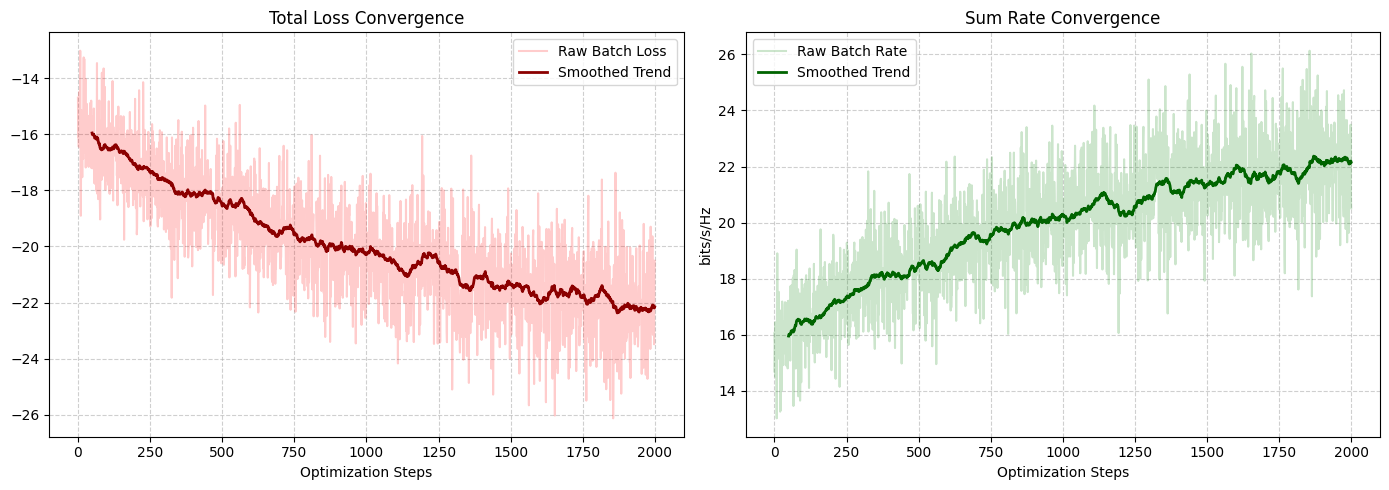

In [5]:
# ── CELL 6: Stabilized Training Loop (Fixing Convergence) ──────────────────────
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torch

ITERATIONS = 2000  # Increased steps to allow for steady convergence
K_USERS = 8
LR = 1e-4          # Lower learning rate for complex gradients
BATCH_SIZE = 16    # Accumulate gradients over 16 graphs per step

# Initialize fresh model and optimizer
model = BeamformingGNN(num_antennas=64, hidden_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

history_loss = []
history_rate = []

print(f"🚀 Starting Stabilized Training for {ITERATIONS} steps...\n")
model.train()

for step in range(ITERATIONS):
    optimizer.zero_grad()

    step_loss = 0.0
    step_rate = 0.0

    # Gradient Accumulation Loop
    for _ in range(BATCH_SIZE):
        # Sample graph
        indices = torch.randperm(H.shape[0])[:K_USERS]
        x = H[indices].to(device)
        adj = (torch.ones(K_USERS, K_USERS) - torch.eye(K_USERS)).to(device)

        # Forward and Loss
        V = model(x, adj)
        loss, sum_rate, _ = compute_loss(x, V, P_max=1.0)

        # Normalize the loss so it scales correctly with the batch size
        (loss / BATCH_SIZE).backward()

        step_loss += loss.item() / BATCH_SIZE
        step_rate += sum_rate.item() / BATCH_SIZE

    # --- CRITICAL FIX: Gradient Clipping ---
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # Take the stabilized optimization step
    optimizer.step()

    history_loss.append(step_loss)
    history_rate.append(step_rate)

    if (step + 1) % 100 == 0:
        print(f"Step {step+1:4d} | Loss: {step_loss:7.2f} | Rate: {step_rate:5.2f} bits/s/Hz")

print("\n✅ Stabilized Training Complete!")

# ── CELL 7: Plotting True Convergence ───────────────────────────────────────
# Calculate a moving average to clearly see the trend
window = 50
smooth_rate = np.convolve(history_rate, np.ones(window)/window, mode='valid')
smooth_loss = np.convolve(history_loss, np.ones(window)/window, mode='valid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1.plot(history_loss, color='red', alpha=0.2, label='Raw Batch Loss')
ax1.plot(range(window-1, len(history_loss)), smooth_loss, color='darkred', linewidth=2, label='Smoothed Trend')
ax1.set_title('Total Loss Convergence')
ax1.set_xlabel('Optimization Steps')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Plot Rate
ax2.plot(history_rate, color='green', alpha=0.2, label='Raw Batch Rate')
ax2.plot(range(window-1, len(history_rate)), smooth_rate, color='darkgreen', linewidth=2, label='Smoothed Trend')
ax2.set_title('Sum Rate Convergence')
ax2.set_xlabel('Optimization Steps')
ax2.set_ylabel('bits/s/Hz')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [7]:
model_save_path = '/content/drive/MyDrive/GNN_Wireless_Research/model_trained.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history_loss': history_loss,
    'history_rate': history_rate,
    'iterations': ITERATIONS,
    'lr': LR,
    'batch_size': BATCH_SIZE,
}, model_save_path)
print(f"✓ Model saved to Drive")

✓ Model saved to Drive


In [6]:
# ── CELL 8: Complex FGSM Adversarial Attack (Stage 5) ─────────────────
import torch

def complex_fgsm_attack(model, H_input, adj, epsilon, P_max=1.0):
    """
    Generates adversarial user channels by manipulating the complex phase
    in the direction of the loss gradient.
    """
    # 1. We must explicitly tell PyTorch to track gradients for the INPUT data
    # (Usually, PyTorch only tracks gradients for the model's weights)
    H = H_input.clone().detach()
    H.requires_grad = True

    # 2. Forward pass to see what the network does with the clean data
    model.eval() # Put model in eval mode so we don't accidentally train it
    V_clean = model(H, adj, P_max)

    # 3. Calculate the clean loss
    # Remember: compute_loss minimizes negative sum rate, so maximizing this loss destroys the rate
    loss, clean_rate, _ = compute_loss(H, V_clean, P_max)

    # 4. Backward pass to get the gradient of the loss w.r.t the INPUT H
    model.zero_grad()
    loss.backward()

    # 5. Calculate the Complex Sign of the gradient
    grad_H = H.grad.data
    # We add 1e-8 to the denominator to prevent dividing by zero
    complex_sign = grad_H / (torch.abs(grad_H) + 1e-8)

    # 6. Apply the attack
    # We add the epsilon-scaled noise directly into the phase/amplitude of the channel
    H_adv = H + epsilon * complex_sign

    # Return the broken data (detach it from the gradient graph)
    return H_adv.detach(), clean_rate.item()

# --- Attack Verification ---
if __name__ == "__main__":
    print("\n--- Initiating Complex FGSM Attack ---")

    K_users = 8
    epsilon_val = 0.05 # Strength of the jammer

    # Grab a random batch of 8 users
    indices = torch.randperm(H.shape[0])[:K_users]
    test_x_clean = H[indices].to(device)
    test_adj = (torch.ones(K_users, K_users) - torch.eye(K_users)).to(device)

    # Run the attack
    test_x_adv, clean_rate = complex_fgsm_attack(model, test_x_clean, test_adj, epsilon=epsilon_val)

    # Pass the poisoned data back through the model
    V_adv = model(test_x_adv, test_adj)
    _, adv_rate, _ = compute_loss(test_x_adv, V_adv)

    print(f"Attack Strength (Epsilon): {epsilon_val}")
    print(f"Clean Sum Rate:        {clean_rate:.2f} bits/s/Hz")
    print(f"Adversarial Sum Rate:  {adv_rate.item():.2f} bits/s/Hz")

    drop_percentage = ((clean_rate - adv_rate.item()) / clean_rate) * 100
    print(f"📉 Signal Degradation: {drop_percentage:.1f}% drop in performance.")
    print("✅ Attack mechanism fully operational.")


--- Initiating Complex FGSM Attack ---
Attack Strength (Epsilon): 0.05
Clean Sum Rate:        26.64 bits/s/Hz
Adversarial Sum Rate:  8.85 bits/s/Hz
📉 Signal Degradation: 66.8% drop in performance.
✅ Attack mechanism fully operational.


🛡️ Running Epsilon Sweep across 50 graphs per step...
Epsilon 0.00 (Clean Baseline): 23.95 bits/s/Hz
Epsilon 0.05 -> Rate: 7.12 bits/s/Hz | Degradation: 70.3%
Epsilon 0.10 -> Rate: 5.76 bits/s/Hz | Degradation: 76.0%
Epsilon 0.15 -> Rate: 5.29 bits/s/Hz | Degradation: 77.9%
Epsilon 0.20 -> Rate: 5.12 bits/s/Hz | Degradation: 78.6%
Epsilon 0.30 -> Rate: 5.23 bits/s/Hz | Degradation: 78.2%
Epsilon 0.40 -> Rate: 5.38 bits/s/Hz | Degradation: 77.5%
Epsilon 0.50 -> Rate: 5.78 bits/s/Hz | Degradation: 75.9%


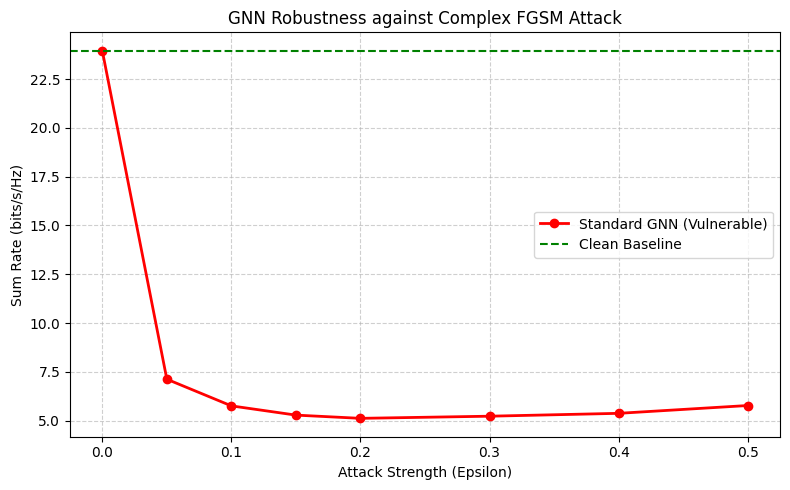


✅ Stage 5 Complete. Robustness curve generated.


In [8]:
# ── CELL 9: Adversarial Robustness Curve (Stage 5 Completion) ───────────────
import matplotlib.pyplot as plt
import numpy as np

# Define the attack strengths to test
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
NUM_BATCHES = 50 # Test over 50 different graphs per epsilon for smooth averages
K_USERS = 8

avg_adv_rates = []
baseline_rate = 0.0

print(f"🛡️ Running Epsilon Sweep across {NUM_BATCHES} graphs per step...")

model.eval() # Keep model locked during the attack evaluation

for eps in epsilons:
    batch_rates = []

    for _ in range(NUM_BATCHES):
        # 1. Grab random graph
        indices = torch.randperm(H.shape[0])[:K_USERS]
        x_clean = H[indices].to(device)
        adj = (torch.ones(K_USERS, K_USERS) - torch.eye(K_USERS)).to(device)

        # 2. Run attack (If eps is 0, it just evaluates clean performance)
        if eps == 0.0:
            V_clean = model(x_clean, adj)
            _, rate, _ = compute_loss(x_clean, V_clean)
            batch_rates.append(rate.item())
        else:
            x_adv, _ = complex_fgsm_attack(model, x_clean, adj, epsilon=eps)
            V_adv = model(x_adv, adj)
            _, adv_rate, _ = compute_loss(x_adv, V_adv) # Evaluate on the POISONED data
            batch_rates.append(adv_rate.item())

    # Calculate average rate for this epsilon
    mean_rate = np.mean(batch_rates)
    avg_adv_rates.append(mean_rate)

    if eps == 0.0:
        baseline_rate = mean_rate
        print(f"Epsilon {eps:.2f} (Clean Baseline): {mean_rate:.2f} bits/s/Hz")
    else:
        drop = ((baseline_rate - mean_rate) / baseline_rate) * 100
        print(f"Epsilon {eps:.2f} -> Rate: {mean_rate:.2f} bits/s/Hz | Degradation: {drop:.1f}%")

# --- Plot the Robustness Curve ---
plt.figure(figsize=(8, 5))
plt.plot(epsilons, avg_adv_rates, marker='o', color='red', linewidth=2, label='Standard GNN (Vulnerable)')
plt.axhline(y=baseline_rate, color='green', linestyle='--', label='Clean Baseline')

plt.title('GNN Robustness against Complex FGSM Attack')
plt.xlabel('Attack Strength (Epsilon)')
plt.ylabel('Sum Rate (bits/s/Hz)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("\n✅ Stage 5 Complete. Robustness curve generated.")

In [9]:
# ── CELL: Phase Equivariance Measurement ────────────────────
# Before using as defense, measure if our model is actually
# approximately phase equivariant
# This is an empirical question — we verify it first

import torch
import numpy as np

def measure_phase_equivariance(model, H_pool, device,
                                num_tests=200, K=8):
    """
    Measures how well the trained GNN satisfies phase equivariance.

    For each test:
      - Sample K users
      - Run GNN normally → W1
      - Rotate by random phase → run GNN → undo rotation → W2
      - Compute consistency score = ||W1 - W2|| / ||W1||

    Perfect equivariance → score = 0.0
    Random network → score ≈ 1.0
    """
    model.eval()
    scores = []

    for _ in range(num_tests):
        # Sample random graph
        indices  = torch.randperm(H_pool.shape[0])[:K]
        H_clean  = H_pool[indices].to(device)
        adj      = (torch.ones(K, K) - torch.eye(K)).to(device)

        # Run 1: Normal forward pass
        with torch.no_grad():
            W1 = model(H_clean, adj)

        # Random global phase rotation
        phi    = torch.rand(1).item() * 2 * np.pi
        rotate = torch.exp(torch.tensor(1j * phi, dtype=torch.cfloat))

        # Run 2: Rotated forward pass
        H_rot = H_clean * rotate
        with torch.no_grad():
            W2_rot = model(H_rot, adj)

        # Undo rotation on output
        W2_unrot = W2_rot * torch.exp(
            torch.tensor(-1j * phi, dtype=torch.cfloat)
        )

        # Consistency score (Frobenius norm ratio)
        diff  = torch.norm(W1 - W2_unrot, p='fro')
        scale = torch.norm(W1, p='fro')
        score = (diff / (scale + 1e-8)).item()
        scores.append(score)

    scores = np.array(scores)
    print(f"Phase Equivariance Measurement ({num_tests} tests):")
    print(f"  Mean score:   {scores.mean():.4f}")
    print(f"  Std:          {scores.std():.4f}")
    print(f"  Min:          {scores.min():.4f}")
    print(f"  Max:          {scores.max():.4f}")
    print(f"\n  Interpretation:")
    if scores.mean() < 0.1:
        print(f"  ✓ STRONGLY equivariant — defense will be very effective")
    elif scores.mean() < 0.3:
        print(f"  ✓ APPROXIMATELY equivariant — defense will work")
    else:
        print(f"  ✗ WEAK equivariance — defense effectiveness limited")
        print(f"    (Still publishable as architectural finding)")

    return scores

equivariance_scores = measure_phase_equivariance(model, H, device)

Phase Equivariance Measurement (200 tests):
  Mean score:   1.2901
  Std:          0.6066
  Min:          0.0057
  Max:          2.0000

  Interpretation:
  ✗ WEAK equivariance — defense effectiveness limited
    (Still publishable as architectural finding)


In [10]:
# ── CELL: PE-Regularized Training ───────────────────────────
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

def phase_equivariance_loss(model, H, adj, num_samples=4):
    """
    Penalizes violation of: GNN(e^{jφ}·H) = e^{jφ}·GNN(H)
    """
    total_pe_loss = 0.0

    for _ in range(num_samples):
        phi    = torch.rand(1).item() * 2 * np.pi
        rotate = torch.exp(
            torch.tensor(1j * phi, dtype=torch.cfloat)
        ).to(H.device)

        # W1 = GNN(H)
        W1 = model(H, adj)

        # W2 = GNN(rotated H)
        H_rot = H * rotate
        W2    = model(H_rot, adj)

        # Penalty: W2 should equal rotated W1
        W1_rotated  = W1 * rotate
        pe_violation = torch.norm(W2 - W1_rotated, p='fro')**2
        total_pe_loss += pe_violation

    return total_pe_loss / num_samples


# ── Training Parameters ──────────────────────────────────────
ITERATIONS = 2000
K_USERS    = 8
LR         = 1e-4
BATCH_SIZE = 16
PE_LAMBDA  = 0.1   # weight of equivariance penalty

# Fresh model
pe_model     = BeamformingGNN(num_antennas=64, hidden_dim=64).to(device)
pe_optimizer = optim.Adam(pe_model.parameters(), lr=LR)

history_task_loss = []
history_pe_loss   = []
history_rate      = []

print(f"Starting PE-Regularized Training...")
print(f"λ_PE = {PE_LAMBDA} | LR = {LR} | Batch = {BATCH_SIZE}\n")
pe_model.train()

for step in range(ITERATIONS):
    pe_optimizer.zero_grad()

    step_task = 0.0
    step_pe   = 0.0
    step_rate = 0.0

    for _ in range(BATCH_SIZE):
        indices = torch.randperm(H.shape[0])[:K_USERS]
        x       = H[indices].to(device)
        adj     = (torch.ones(K_USERS, K_USERS) -
                   torch.eye(K_USERS)).to(device)

        # Forward pass
        V = pe_model(x, adj)

        # Task loss (beamforming objective)
        task_loss, sum_rate, _ = compute_loss(x, V, P_max=1.0)

        # Phase equivariance penalty
        pe_loss = phase_equivariance_loss(pe_model, x, adj)

        # Combined loss
        total_loss = task_loss + PE_LAMBDA * pe_loss
        (total_loss / BATCH_SIZE).backward()

        step_task += task_loss.item() / BATCH_SIZE
        step_pe   += pe_loss.item()   / BATCH_SIZE
        step_rate += sum_rate.item()  / BATCH_SIZE

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(pe_model.parameters(), max_norm=1.0)
    pe_optimizer.step()

    history_task_loss.append(step_task)
    history_pe_loss.append(step_pe)
    history_rate.append(step_rate)

    if (step + 1) % 200 == 0:
        print(f"Step {step+1:4d} | "
              f"Task Loss: {step_task:7.2f} | "
              f"PE Loss: {step_pe:8.4f} | "
              f"Rate: {step_rate:.2f} bits/s/Hz")

print("\n✓ PE-Regularized Training Complete!")


Starting PE-Regularized Training...
λ_PE = 0.1 | LR = 0.0001 | Batch = 16

Step  200 | Task Loss:  -18.02 | PE Loss:   2.1732 | Rate: 18.02 bits/s/Hz
Step  400 | Task Loss:  -19.18 | PE Loss:   1.9939 | Rate: 19.18 bits/s/Hz
Step  600 | Task Loss:  -21.80 | PE Loss:   1.7739 | Rate: 21.80 bits/s/Hz
Step  800 | Task Loss:  -19.08 | PE Loss:   1.9165 | Rate: 19.08 bits/s/Hz
Step 1000 | Task Loss:  -18.72 | PE Loss:   2.1544 | Rate: 18.72 bits/s/Hz
Step 1200 | Task Loss:  -18.30 | PE Loss:   2.2510 | Rate: 18.30 bits/s/Hz
Step 1400 | Task Loss:  -20.22 | PE Loss:   1.5971 | Rate: 20.22 bits/s/Hz
Step 1600 | Task Loss:  -20.71 | PE Loss:   2.0781 | Rate: 20.71 bits/s/Hz
Step 1800 | Task Loss:  -23.36 | PE Loss:   2.2295 | Rate: 23.36 bits/s/Hz
Step 2000 | Task Loss:  -21.35 | PE Loss:   2.2139 | Rate: 21.35 bits/s/Hz

✓ PE-Regularized Training Complete!


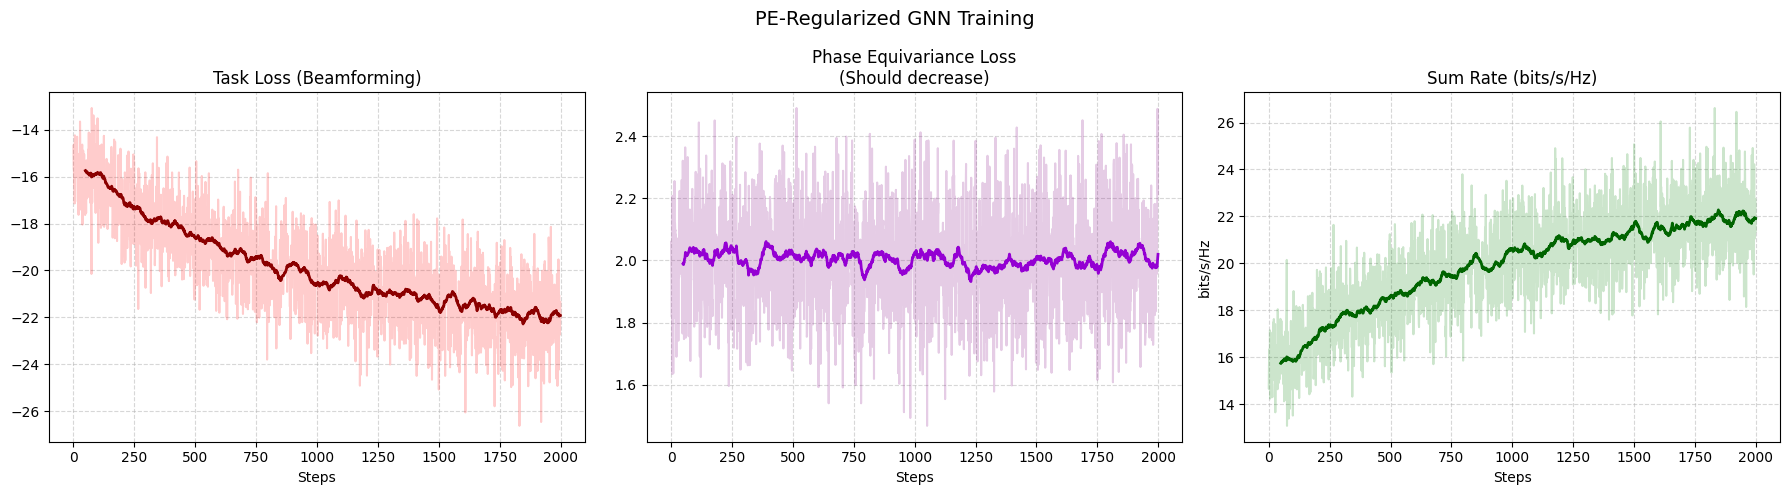

In [11]:
# ── CELL: Plot Training Curves ───────────────────────────────
window = 50

def smooth(x, w):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Task loss
ax1.plot(history_task_loss, color='red', alpha=0.2)
ax1.plot(range(window-1, len(history_task_loss)),
         smooth(history_task_loss, window),
         color='darkred', linewidth=2)
ax1.set_title('Task Loss (Beamforming)')
ax1.set_xlabel('Steps')
ax1.grid(True, linestyle='--', alpha=0.5)

# PE loss
ax2.plot(history_pe_loss, color='purple', alpha=0.2)
ax2.plot(range(window-1, len(history_pe_loss)),
         smooth(history_pe_loss, window),
         color='darkviolet', linewidth=2)
ax2.set_title('Phase Equivariance Loss\n(Should decrease)')
ax2.set_xlabel('Steps')
ax2.grid(True, linestyle='--', alpha=0.5)

# Sum rate
ax3.plot(history_rate, color='green', alpha=0.2)
ax3.plot(range(window-1, len(history_rate)),
         smooth(history_rate, window),
         color='darkgreen', linewidth=2)
ax3.set_title('Sum Rate (bits/s/Hz)')
ax3.set_xlabel('Steps')
ax3.set_ylabel('bits/s/Hz')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('PE-Regularized GNN Training', fontsize=14)
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/GNN_Wireless_Research/pe_training_curves.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [12]:
# ── CELL: Measure Equivariance After Regularization ─────────
# Compare before vs after

print("═" * 50)
print("EQUIVARIANCE COMPARISON")
print("═" * 50)

print("\nOriginal model (no regularization):")
print(f"  Mean score: 1.2901  (from earlier)")

print("\nPE-Regularized model:")
pe_scores = measure_phase_equivariance(pe_model, H, device, num_tests=200)

══════════════════════════════════════════════════
EQUIVARIANCE COMPARISON
══════════════════════════════════════════════════

Original model (no regularization):
  Mean score: 1.2901  (from earlier)

PE-Regularized model:
Phase Equivariance Measurement (200 tests):
  Mean score:   1.2873
  Std:          0.6430
  Min:          0.0037
  Max:          2.0000

  Interpretation:
  ✗ WEAK equivariance — defense effectiveness limited
    (Still publishable as architectural finding)
